In [3]:
# Starting the code for the assignment / Importing main libraries
import pandas as pd  #csv Imported
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
df = pd.read_csv('ford_car_dataset.csv')

df #Prints

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0
...,...,...,...,...,...,...,...,...,...
17961,B-MAX,2017,8999,Manual,16700,Petrol,150,47.1,1.4
17962,B-MAX,2014,7499,Manual,40700,Petrol,30,57.7,1.0
17963,Focus,2015,9999,Manual,7010,Diesel,20,67.3,1.6
17964,KA,2018,8299,Manual,5007,Petrol,145,57.7,1.2


In [4]:
#Quesition 1: Print the first 10 rows of the dataset, last 5 rows of the dataset,
# shape of the dataset and datatypes of all columns in the dataset.

print("The first 10 rows of the dataset are:")
print(df.head(10)) #Prints the first 10 rows of the dataset

print("\nThe last 5 rows from the dataset are:")
print(df.tail(5)) #Prints the last 5 rows of the dataset

print("\nThe shape of the dataset is:")
print(df.shape) #Prints the shape of the dataset

print("\nThe datatypes of all columns in the dataset are:")
print(df.dtypes) #Prints the datatypes of all columns in the dataset

The first 10 rows of the dataset are:
     model  year  price transmission  mileage fuelType  tax   mpg  engineSize
0   Fiesta  2017  12000    Automatic    15944   Petrol  150  57.7         1.0
1    Focus  2018  14000       Manual     9083   Petrol  150  57.7         1.0
2    Focus  2017  13000       Manual    12456   Petrol  150  57.7         1.0
3   Fiesta  2019  17500       Manual    10460   Petrol  145  40.3         1.5
4   Fiesta  2019  16500    Automatic     1482   Petrol  145  48.7         1.0
5   Fiesta  2015  10500       Manual    35432   Petrol  145  47.9         1.6
6     Puma  2019  22500       Manual     2029   Petrol  145  50.4         1.0
7   Fiesta  2017   9000       Manual    13054   Petrol  145  54.3         1.2
8     Kuga  2019  25500    Automatic     6894   Diesel  145  42.2         2.0
9    Focus  2018  10000       Manual    48141   Petrol  145  61.4         1.0

The last 5 rows from the dataset are:
        model  year  price transmission  mileage fuelType  tax   

# Observtion 
1. Most of the data is in integer int64
2. Dataset is about Ford Automobile
3. Most of the cars have manual Tansmission 

In [5]:
# Question 2: Check for missing values and remove duplicate rows from the dataset

print("The total number of missing values in each column:")
print(df.isnull().sum())

print("\nDuplicate rows in the dataset:")
print(df.duplicated().sum())   # Number of duplicate rows before removal

# Remove duplicate rows
df = df.drop_duplicates()

print("\nNumber of duplicate rows after removal:")
print(df.duplicated().sum())   # Should print 0

# isnull() identifies missing values in the dataset.
# sum() counts the total number of missing values in each column.
# duplicated() identifies duplicate rows.
# drop_duplicates() removes duplicate rows from the dataset.

The total number of missing values in each column:
model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64

Duplicate rows in the dataset:
154

Number of duplicate rows after removal:
0


In [6]:
# Question 3: Generate Statistical Summary

print("Statistical Summary of All Numeric Columns:\n")
print(df.describe().round(2))

# Display minimum, maximum, mean, and median for selected columns
columns = ["price", "mileage", "year"]

for col in columns:
    print(f"\nStatistics for {col}:")
    print("Minimum :", df[col].min())
    print("Maximum :", df[col].max())
    print("Mean    :", round(df[col].mean(), 2))
    print("Median  :", df[col].median())

# describe() generates summary statistics for all numeric columns.
# min() returns the minimum value.
# max() returns the maximum value.
# mean() returns the average value.
# median() returns the middle value after sorting the data.

Statistical Summary of All Numeric Columns:

           year     price    mileage       tax       mpg  engineSize
count  17812.00  17812.00   17812.00  17812.00  17812.00    17812.00
mean    2016.86  12269.56   23381.15    113.32     57.91        1.35
std        2.05   4736.29   19419.01     62.03     10.13        0.43
min     1996.00    495.00       1.00      0.00     20.80        0.00
25%     2016.00   8999.00   10000.00     30.00     52.30        1.00
50%     2017.00  11288.00   18277.00    145.00     58.90        1.20
75%     2018.00  15295.00   31098.50    145.00     65.70        1.50
max     2060.00  54995.00  177644.00    580.00    201.80        5.00

Statistics for price:
Minimum : 495
Maximum : 54995
Mean    : 12269.56
Median  : 11288.0

Statistics for mileage:
Minimum : 1
Maximum : 177644
Mean    : 23381.15
Median  : 18277.0

Statistics for year:
Minimum : 1996
Maximum : 2060
Mean    : 2016.86
Median  : 2017.0


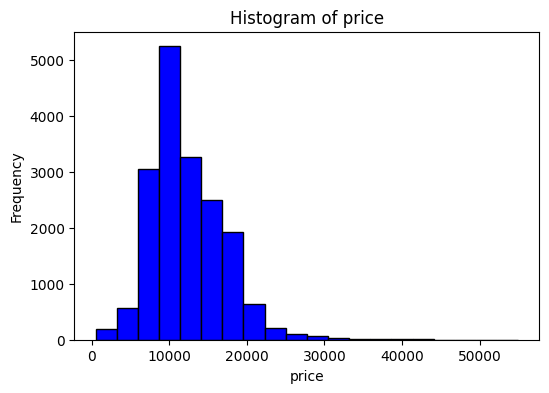

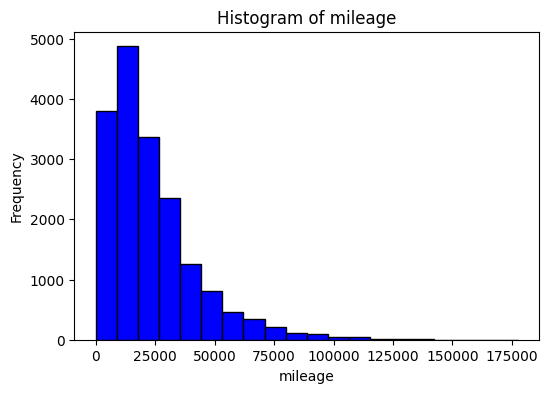

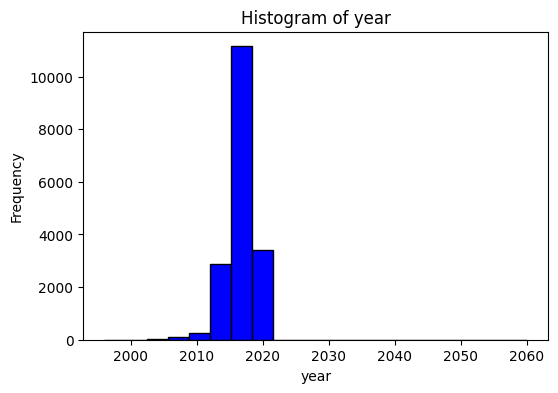

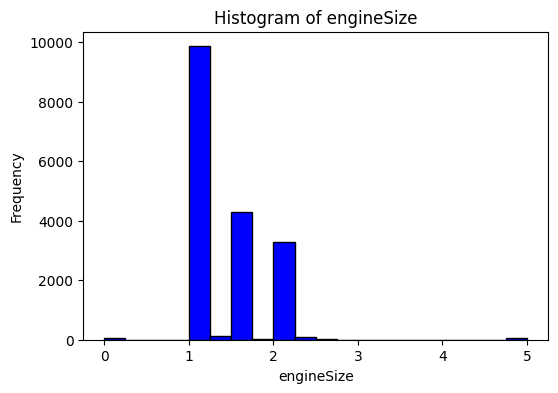

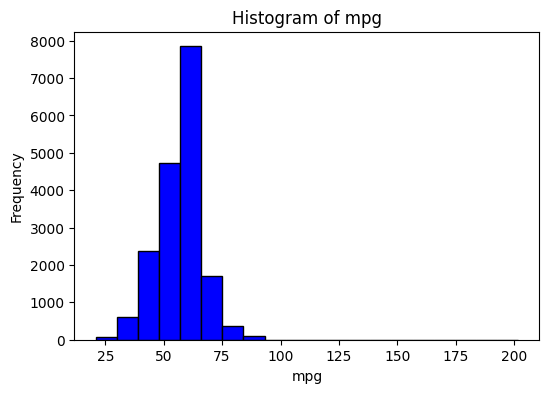

In [7]:
# Question 4: Histogram of Numeric Features

numeric_columns_distribution = ["price", "mileage", "year", "engineSize", "mpg"]

for col in numeric_columns_distribution:
    plt.figure(figsize=(6,4))
    plt.hist(df[col], bins=20, color="blue", edgecolor="black")
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

# Findings:
# Year: Most cars are from recent years.
# Price: Most cars have lower prices, while only a few are very expensive.
# Mileage: Most cars have average mileage, and very high mileage cars are fewer.
# Engine Size: Smaller engine sizes are more common than larger ones.
# MPG: Most cars have average fuel efficiency, with only a few having very low or very high MPG.

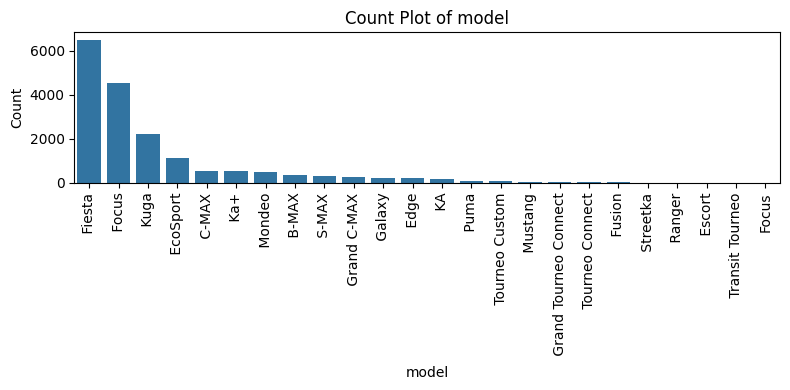

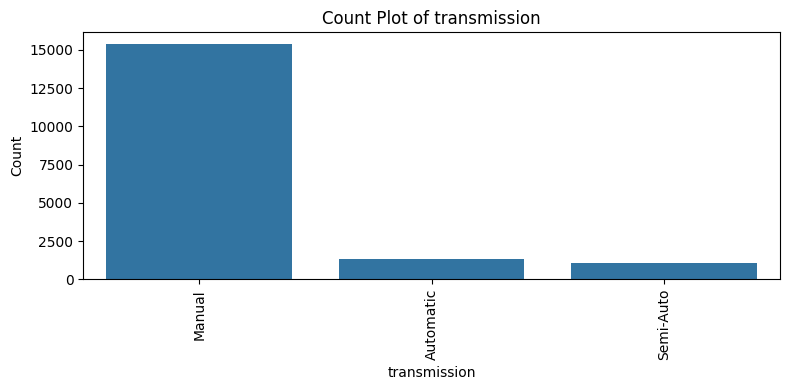

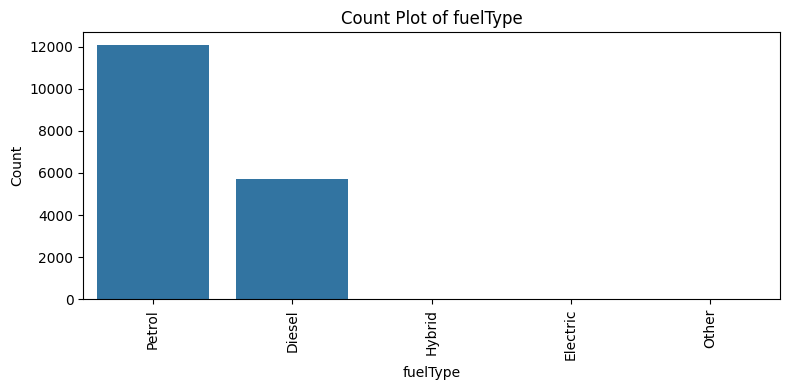

In [8]:
# Question 5: Count Plots of Categorical Features

# Select all categorical columns
categorical_columns = df.select_dtypes(include="object").columns

for col in categorical_columns:
    plt.figure(figsize=(8,4))
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.title(f"Count Plot of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

# Analysis:
# Fuel Type: Petrol and diesel are the most common fuel types.
# Transmission: Automatic and manual transmissions have the highest counts.
# Model: Models like Fiesta , Focus, and kuga appear most frequently.
# Overall: Popular Ford models with common fuel types and transmissions dominate the market.

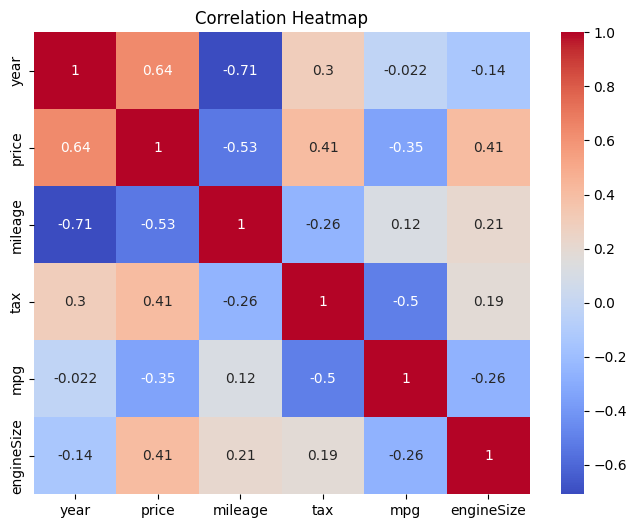


Correlation with Price:
price         1.000000
year          0.635715
engineSize    0.411451
tax           0.405969
mpg          -0.346263
mileage      -0.530483
Name: price, dtype: float64


In [ ]:
# Question 6: Correlation Heatmap for numeric columns
correlation = df.corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(correlation, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# Correlation of numeric features with price
print("\nCorrelation with Price:")
print(correlation["price"].sort_values(ascending=False))


# Observations:
# Price has a strong positive correlation with year and engineSize.
# Price has a negative correlation with mileage.
# MPG has a weak or negative correlation with price.
# Newer cars with larger engines generally have higher prices.
# Cars with higher mileage usually have lower prices.

In [10]:
# Question 7: Feature Identification

print("Independent Features (Input Features):")
print(df.drop("price", axis=1).columns.tolist())

print("\nDependent Feature (Target Feature):")
print("price")

# Reason:
# Independent features are the input variables used to predict the car price.
# The dependent feature is 'price' because it is the output value we want to predict.
# Features like mileage, year, engineSize, fuelType, transmission, and model
# influence the selling price of a car.

Independent Features (Input Features):
['model', 'year', 'transmission', 'mileage', 'fuelType', 'tax', 'mpg', 'engineSize']

Dependent Feature (Target Feature):
price


In [11]:
# Question 8: Encoding Categorical Variables

# Display original values of two categorical columns
print("Before One-Hot Encoding:\n")
print(df[["fuelType", "transmission"]].head())

# Apply One-Hot Encoding
encoded_df = pd.get_dummies(df, drop_first=True)

# Display encoded values
print("\nAfter One-Hot Encoding:\n")
print(encoded_df.head())

Before One-Hot Encoding:

  fuelType transmission
0   Petrol    Automatic
1   Petrol       Manual
2   Petrol       Manual
3   Petrol       Manual
4   Petrol    Automatic

After One-Hot Encoding:

   year  price  mileage  tax   mpg  engineSize  model_ C-MAX  model_ EcoSport  \
0  2017  12000    15944  150  57.7         1.0         False            False   
1  2018  14000     9083  150  57.7         1.0         False            False   
2  2017  13000    12456  150  57.7         1.0         False            False   
3  2019  17500    10460  145  40.3         1.5         False            False   
4  2019  16500     1482  145  48.7         1.0         False            False   

   model_ Edge  model_ Escort  ...  model_ Tourneo Connect  \
0        False          False  ...                   False   
1        False          False  ...                   False   
2        False          False  ...                   False   
3        False          False  ...                   False   
4      

In [ ]:
# Question 9: Feature Scaling
# Select numeric independent features (excluding the target variable 'price')
X = df.drop("price", axis=1).select_dtypes(include=["int64", "float64"])

# Create the StandardScaler object
scaler = StandardScaler()

# Scale the numeric features
scaled_data = scaler.fit_transform(X)

# Convert the scaled data into a DataFrame
scaled_df = pd.DataFrame(scaled_data, columns=X.columns)

# Display the first 5 rows
print("First 5 rows of the scaled data:")
print(scaled_df.head())

# StandardScaler scales the data so that each feature has
# a mean of 0 and a standard deviation of 1.
# This helps machine learning models perform better.

First 5 rows of the scaled data:
       year   mileage       tax       mpg  engineSize
0  0.067059 -0.382994  0.591380 -0.020597   -0.810561
1  0.554393 -0.736317  0.591380 -0.020597   -0.810561
2  0.067059 -0.562616  0.591380 -0.020597   -0.810561
3  1.041726 -0.665405  0.510777 -1.737858    0.345325
4  1.041726 -1.127749  0.510777 -0.908836   -0.810561


Missing Values:
model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64


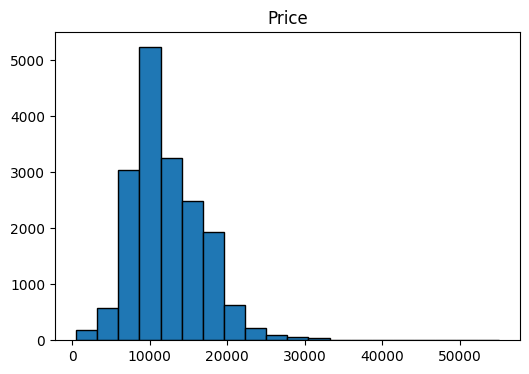

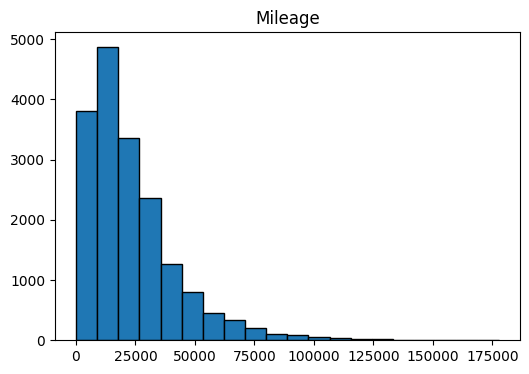

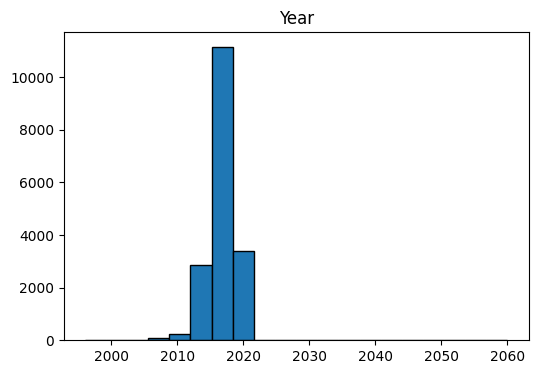

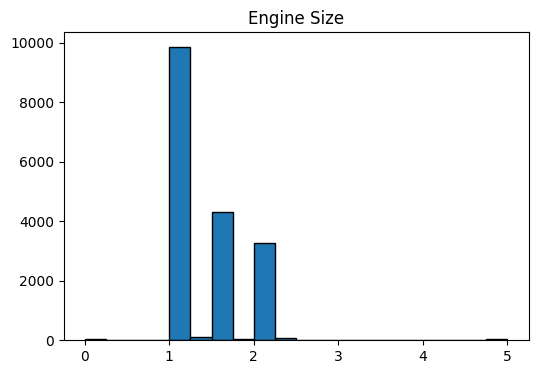

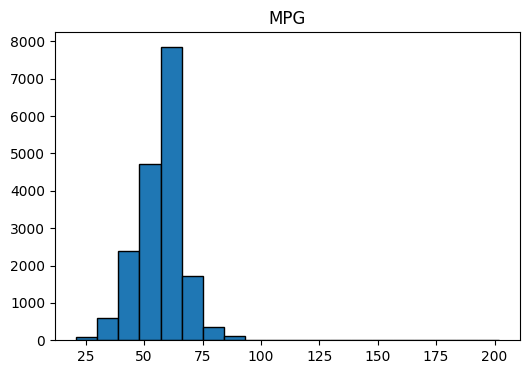

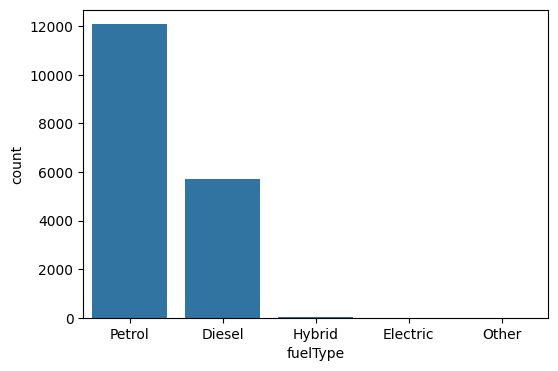

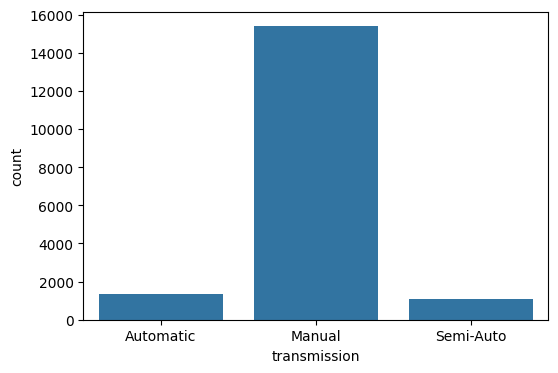

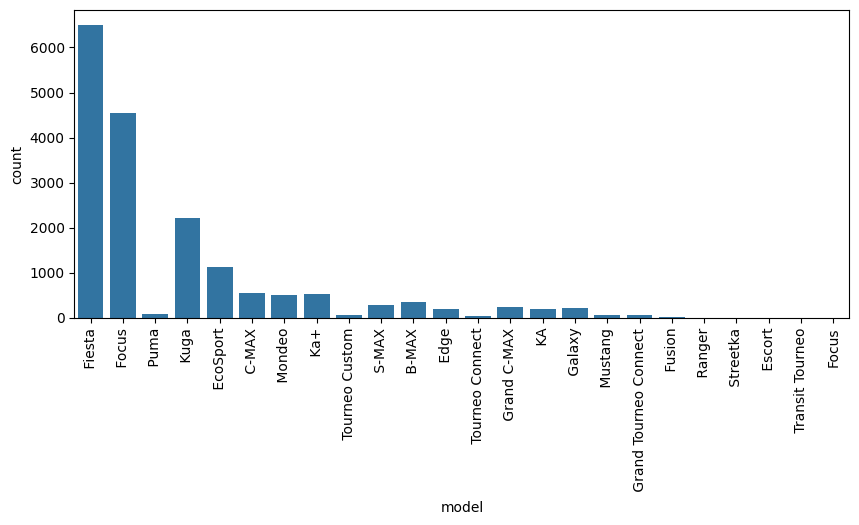

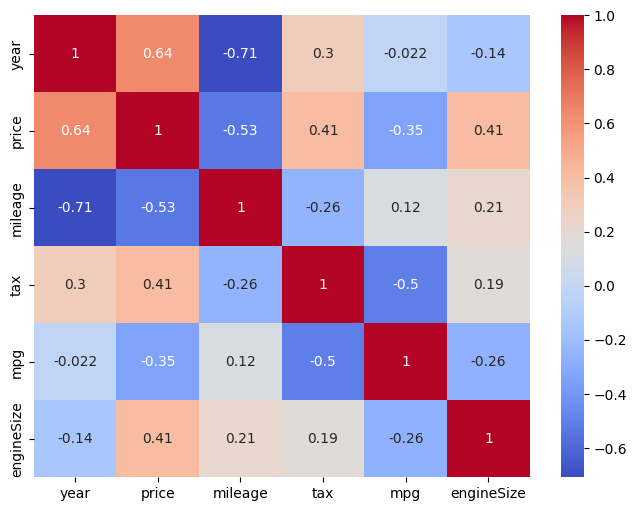


Independent Features:
Index(['model', 'year', 'transmission', 'mileage', 'fuelType', 'tax', 'mpg',
       'engineSize'],
      dtype='object')

Dependent Feature:
price

Before Encoding
  fuelType transmission
0   Petrol    Automatic
1   Petrol       Manual
2   Petrol       Manual
3   Petrol       Manual
4   Petrol    Automatic

After Encoding
   year  price  mileage  tax   mpg  engineSize  model_ C-MAX  model_ EcoSport  \
0  2017  12000    15944  150  57.7         1.0         False            False   
1  2018  14000     9083  150  57.7         1.0         False            False   
2  2017  13000    12456  150  57.7         1.0         False            False   
3  2019  17500    10460  145  40.3         1.5         False            False   
4  2019  16500     1482  145  48.7         1.0         False            False   

   model_ Edge  model_ Escort  ...  model_ Tourneo Connect  \
0        False          False  ...                   False   
1        False          False  ...        

In [ ]:
# Question 10: Complete Preprocessing Pipeline
df = pd.read_csv("ford_car_dataset.csv")

# Check Missing Values
print("Missing Values:")
print(df.isnull().sum())

# Remove Duplicate Rows
df = df.drop_duplicates()

# Histogram of Numeric Features
plt.figure(figsize=(6,4))
plt.hist(df["price"], bins=20, edgecolor="black")
plt.title("Price")
plt.show()

plt.figure(figsize=(6,4))
plt.hist(df["mileage"], bins=20, edgecolor="black")
plt.title("Mileage")
plt.show()

plt.figure(figsize=(6,4))
plt.hist(df["year"], bins=20, edgecolor="black")
plt.title("Year")
plt.show()

plt.figure(figsize=(6,4))
plt.hist(df["engineSize"], bins=20, edgecolor="black")
plt.title("Engine Size")
plt.show()

plt.figure(figsize=(6,4))
plt.hist(df["mpg"], bins=20, edgecolor="black")
plt.title("MPG")
plt.show()

# Count Plots
plt.figure(figsize=(6,4))
sns.countplot(x=df["fuelType"])
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(x=df["transmission"])
plt.show()

plt.figure(figsize=(10,4))
sns.countplot(x=df["model"])
plt.xticks(rotation=90)
plt.show()

# Correlation Heatmap
correlation = df.corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(correlation, annot=True, cmap="coolwarm")
plt.show()

# Independent and Dependent Features
X = df.drop("price", axis=1)
y = df["price"]

print("\nIndependent Features:")
print(X.columns)

print("\nDependent Feature:")
print("price")

# One Hot Encoding
print("\nBefore Encoding")
print(df[["fuelType", "transmission"]].head())

df = pd.get_dummies(df, drop_first=True)

print("\nAfter Encoding")
print(df.head())

# Feature Scaling
X = df.drop("price", axis=1)

scaler = StandardScaler()

X[["year","mileage","tax","mpg","engineSize"]] = scaler.fit_transform(
    X[["year","mileage","tax","mpg","engineSize"]]
)

print("First 5 Rows of Scaled Data")
print(X.head())